In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from perceptron import MultiClassPerceptron

In [2]:
# Load the dataset
df = pd.read_csv('iris/bezdekIris.data')
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

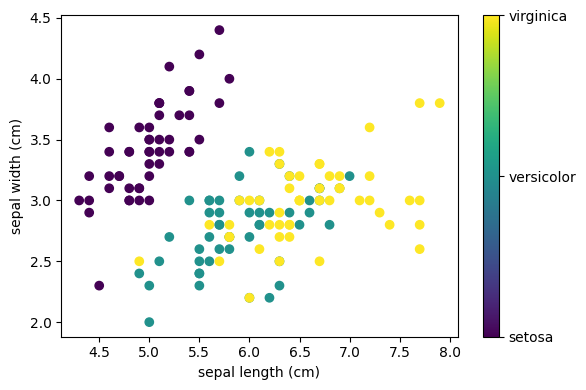

In [3]:
# Plot the figure
class_order = ["Iris-setosa", "Iris-versicolor", "Iris-virginica"]
class_to_id = {c: i for i, c in enumerate(class_order)}
c = df["class"].map(class_to_id)

plt.figure(figsize=(6,4))
sc = plt.scatter(df["sepal_length"], df["sepal_width"], c=c, cmap="viridis")
plt.xlabel("sepal length (cm)")
plt.ylabel("sepal width (cm)")
cb = plt.colorbar(sc, ticks=[0,1,2])
cb.ax.set_yticklabels(["setosa","versicolor","virginica"])
plt.tight_layout()
plt.show()

In [4]:
train_df = df.sample(frac=0.8, random_state=42)
test_df = df.drop(train_df.index)

X_train = train_df[["sepal_length", "sepal_width"]].values
y_train = train_df["class"].map(class_to_id).values

X_test = test_df[["sepal_length", "sepal_width"]].values
y_test = test_df["class"].map(class_to_id).values

In [5]:
perceptron = MultiClassPerceptron(learning_rate=0.01)
perceptron.fit(X_train, y_train)

In [6]:
# Test the perceptron
y_pred = perceptron.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.87
